In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sys

sys.path.append('../')
import ventilation_layer.ventilation_wall_simplified as vws
import ventilation_layer.parameters as pm
from ventilation_layer.heat_transfer_coefficient import HCVMode, HCVModeDetail, HCVModeSimple, HRVMode, HRVModeDetail, HRVModeSimple

# 通気層を有する壁体等の熱的性能のケーススタディ

## 分析用の関数を定義

### 散布図を作成する関数（凡例あり）

In [2]:
def setPltComparison(df: pd.DataFrame, fig_title:str, x_label:str, y_label:str,
                     x_data_name: str, y_data_name: str,
                     query_label:str, query_data_name: str, query_data_list: np.array,
                     xlim_min:float, xlim_max:float, ylim_min:float, ylim_max:float):
    
    # グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
    # グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    
    # フォントサイズを設定
    plt.rcParams["font.size"] = 14
    
    # グラフタイトルを設定
    fig.suptitle(fig_title)
        
    # 補助軸の設定
    ax.grid(which='major', color='gray', linestyle='-')
    ax.grid(which='minor', color='gray', linestyle='-')
        
    # 軸ラベルの設定
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    
    # プロットの色を設定
    colors =['b', 'g', 'r']
    
    # 散布図の描画設定
    for i, data in enumerate(query_data_list):
        x = df.query(query_data_name + ' == ' + str(query_data_list[i]))[x_data_name]
        y = df.query(query_data_name + ' == ' + str(query_data_list[i]))[y_data_name]
        label = query_label + ':' + str(query_data_list[i])
        ax.scatter(x, y, color=colors[i], label= label, s=30, marker=".")
        
    # 軸の描画範囲設定
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    
    # グラフ描画
    plt.legend()
    plt.show()
    

### 散布図を作成する関数（凡例なし）

In [3]:
def setPltComparison_NoLegend(df: pd.DataFrame, fig_title:str, x_label:str, y_label:str,
                     x_data_name: str, y_data_name: str, x_scale_interval: float,
                     xlim_min:float, xlim_max:float, ylim_min:float, ylim_max:float):
    
    # グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
    # グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    
    # フォントサイズを設定
    plt.rcParams["font.size"] = 14
    
    # グラフタイトルを設定
    fig.suptitle(fig_title)
        
    # 補助軸の設定
    ax.grid(which='major', color='gray', linestyle='-')
    ax.grid(which='minor', color='gray', linestyle='-')
        
    # 軸ラベルの設定
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    
    # グラフの描画設定
    x = df[x_data_name]
    y = df[y_data_name]
    plt.plot(x, y, color='b', )
    
    # 軸の描画範囲設定
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    
    # 横軸の間隔を調整
    plt.xticks(np.arange(xlim_min, xlim_max+x_scale_interval, x_scale_interval))
    
    # グラフ描画
    plt.show()
    

# 風速計算の設定

In [4]:
hcv_mode_winter = HCVModeSimple(a=3.939, b=3.289)
hrv_mode_winter = HRVModeSimple(a=5.054)
hcv_mode_summer = HCVModeSimple(a=4.008, b=3.197)
hrv_mode_summer = HRVModeSimple(a=6.615)


# 室内側熱流・修正U値・修正η値

## 共通の計算条件の作成

In [5]:
def make_pmo_winter():
    return pm.ParametersOptions.SetParameters(
        theta_e=[-10.0],
        a_surf=[0.5],
        C_1=[11.0],
        C_2=[2.55],
        l_h=[7.5],
        l_w=[5.025],
        l_d=[0.175],
        angle=[45.0],
        v_a=[0.5],
        emissivity_1=[0.9],
        emissivity_2=[0.5]
    )
def make_pmo_summer():
    return pm.ParametersOptions.SetParameters(
        theta_e=[35.0],
        a_surf=[0.5],
        C_1=[11.0],
        C_2=[2.55],
        l_h=[7.5],
        l_w=[5.025],
        l_d=[0.175],
        angle=[45.0],
        v_a=[0.5],
        emissivity_1=[0.9],
        emissivity_2=[0.5]
    )

## 風速による影響の確認

In [6]:
# 計算条件（冬期）を作成
pmo_winter_v_a = make_pmo_winter()
pmo_summer_v_a = make_pmo_summer()
# 風速条件を追加
pmo_winter_v_a.v_a = np.arange(0.0, 2.0, 0.05)
pmo_summer_v_a.v_a = np.arange(0.0, 2.0, 0.05)

In [7]:
df_winter_v_a = vws.get_datas(pmo=pmo_winter_v_a, hcv_mode=hcv_mode_winter, hrv_mode=hrv_mode_winter)
df_summer_v_a = vws.get_datas(pmo=pmo_summer_v_a, hcv_mode=hcv_mode_summer, hrv_mode=hrv_mode_summer)

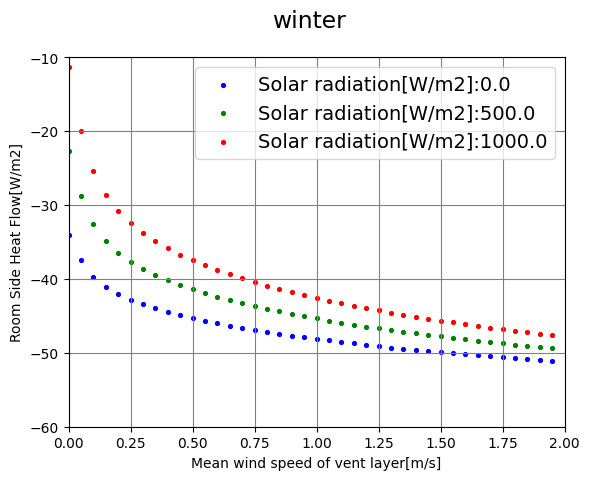

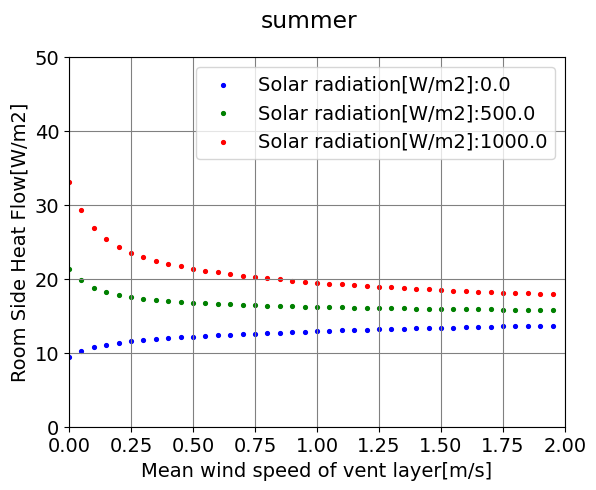

In [8]:

setPltComparison(
    df=df_winter_v_a,
    fig_title='winter',
    x_label='Mean wind speed of vent layer[m/s]',
    y_label='Room Side Heat Flow[W/m2]',
    x_data_name='v_a',
    y_data_name='q_room_side',
    query_label='Solar radiation[W/m2]',
    query_data_name='j_surf',
    query_data_list=pmo_winter_v_a.j_surf,
    xlim_min=0.0,
    xlim_max=2.0,
    ylim_min=-60.0,
    ylim_max=-10.0
)
setPltComparison(
    df=df_summer_v_a,
    fig_title='summer',
    x_label='Mean wind speed of vent layer[m/s]',
    y_label='Room Side Heat Flow[W/m2]',
    x_data_name='v_a',
    y_data_name='q_room_side',
    query_label='Solar radiation[W/m2]',
    query_data_name='j_surf',
    query_data_list=pmo_summer_v_a.j_surf,
    xlim_min=0.0,
    xlim_max=2.0,
    ylim_min=0.0,
    ylim_max=50.0
)

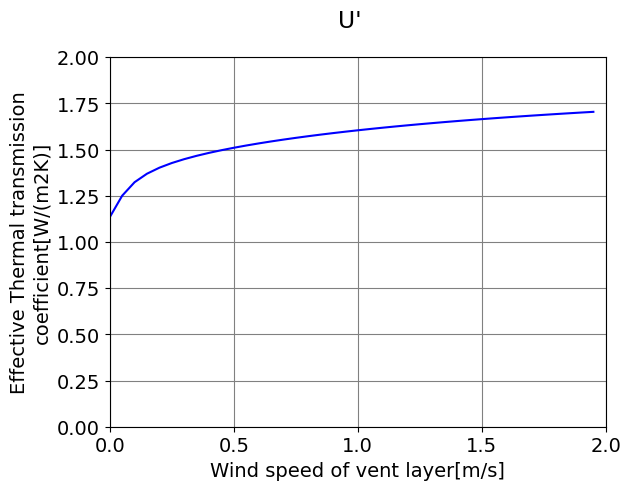

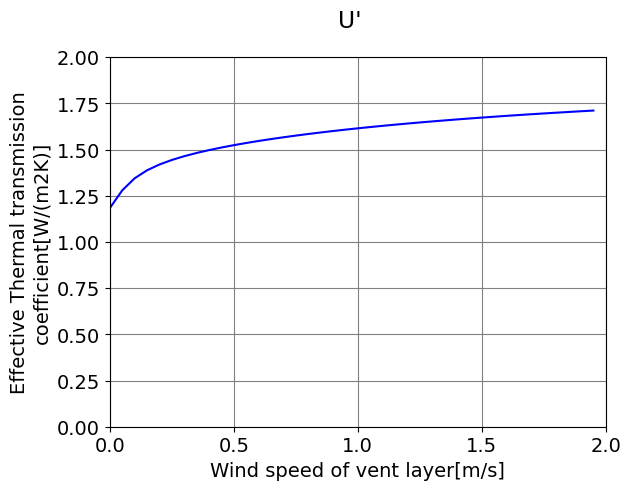

In [9]:
setPltComparison_NoLegend(
    df=df_winter_v_a.query('j_surf == 1000.0'),
    fig_title='U\'',
    x_label='Wind speed of vent layer[m/s]',
    y_label='Effective Thermal transmission\ncoefficient[W/(m2K)]',
    x_data_name='v_a',
    y_data_name='u_dash',
    x_scale_interval = 0.5,
    xlim_min=0.0,
    xlim_max=2.0,
    ylim_min=0.0,
    ylim_max=2.0
)
setPltComparison_NoLegend(
    df=df_summer_v_a.query('j_surf == 1000.0'),
    fig_title='U\'',
    x_label='Wind speed of vent layer[m/s]',
    y_label='Effective Thermal transmission\ncoefficient[W/(m2K)]',
    x_data_name='v_a',
    y_data_name='u_dash',
    x_scale_interval = 0.5,
    xlim_min=0.0,
    xlim_max=2.0,
    ylim_min=0.0,
    ylim_max=2.0
)

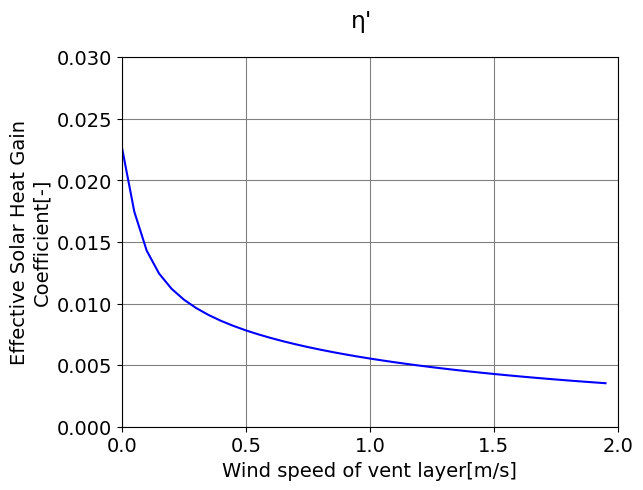

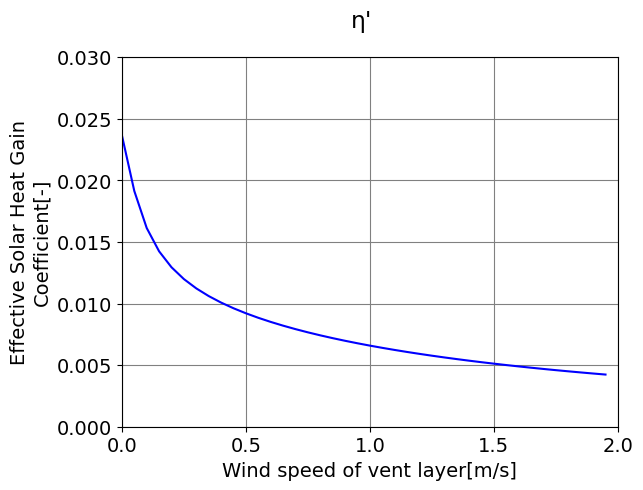

In [10]:
setPltComparison_NoLegend(
    df=df_winter_v_a.query('j_surf == 1000.0'),
    fig_title='η\'',
    x_label='Wind speed of vent layer[m/s]',
    y_label='Effective Solar Heat Gain\nCoefficient[-]',
    x_data_name='v_a',
    y_data_name='eta_dash',
    x_scale_interval = 0.5,
    xlim_min=0.0,
    xlim_max=2.0,
    ylim_min=0.0,
    ylim_max=0.03
)
setPltComparison_NoLegend(
    df=df_summer_v_a.query('j_surf == 1000.0'),
    fig_title='η\'',
    x_label='Wind speed of vent layer[m/s]',
    y_label='Effective Solar Heat Gain\nCoefficient[-]',
    x_data_name='v_a',
    y_data_name='eta_dash',
    x_scale_interval = 0.5,
    xlim_min=0.0,
    xlim_max=2.0,
    ylim_min=0.0,
    ylim_max=0.03
)

## 外気側部材の熱コンダクタンスによる影響の確認

In [11]:
pmo_winter_C_1 = make_pmo_winter()
pmo_summer_C_1 = make_pmo_summer()
pmo_winter_C_1.C_1 = np.arange(0.5, 50.5, 1.5)
pmo_summer_C_1.C_1 = np.arange(0.5, 50.5, 1.5)

In [12]:
df_winter_C_1 = vws.get_datas(pmo=pmo_winter_C_1, hcv_mode=hcv_mode_winter, hrv_mode=hrv_mode_winter)
df_summer_C_1 = vws.get_datas(pmo=pmo_summer_C_1, hcv_mode=hcv_mode_summer, hrv_mode=hrv_mode_summer)

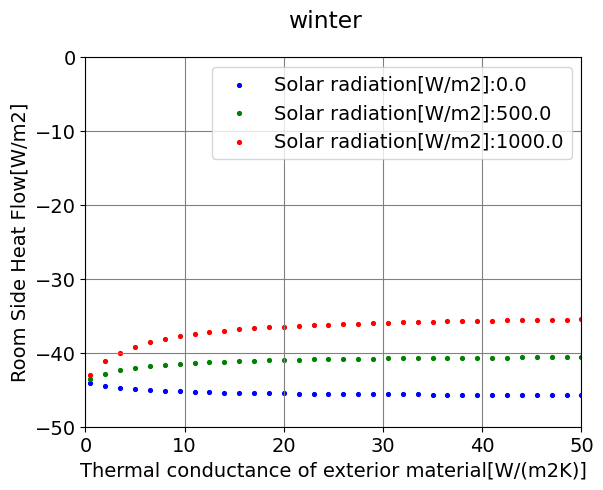

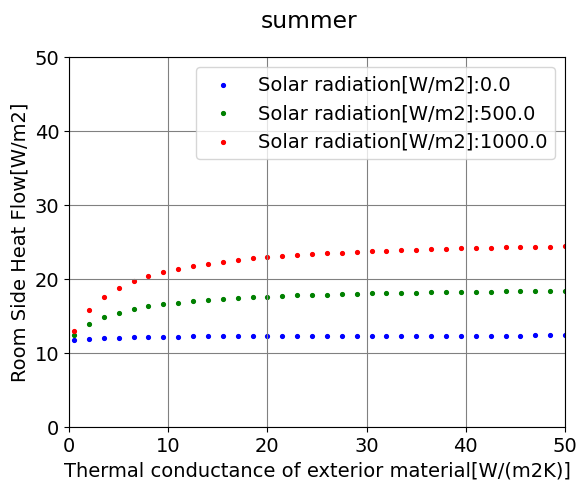

In [13]:
setPltComparison(
    df=df_winter_C_1,
    fig_title='winter',
    x_label='Thermal conductance of exterior material[W/(m2K)]',
    y_label='Room Side Heat Flow[W/m2]',
    x_data_name='C_1', 
    y_data_name='q_room_side',
    query_label='Solar radiation[W/m2]',
    query_data_name='j_surf',
    query_data_list=pmo_winter_C_1.j_surf,
    xlim_min=0.0,
    xlim_max=50.0,
    ylim_min=-50.0,
    ylim_max=0.0
)
setPltComparison(
    df=df_summer_C_1,
    fig_title='summer',
    x_label='Thermal conductance of exterior material[W/(m2K)]',
    y_label='Room Side Heat Flow[W/m2]',
    x_data_name='C_1', 
    y_data_name='q_room_side',
    query_label='Solar radiation[W/m2]',
    query_data_name='j_surf',
    query_data_list=pmo_summer_C_1.j_surf,
    xlim_min=0.0,
    xlim_max=50.0,
    ylim_min=0.0,
    ylim_max=50.0
)

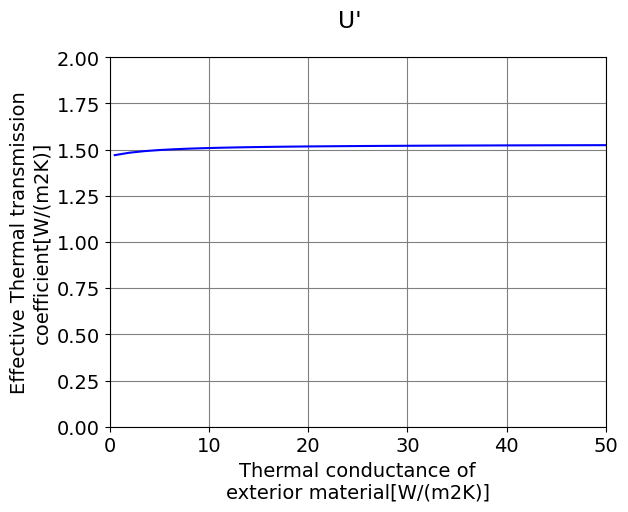

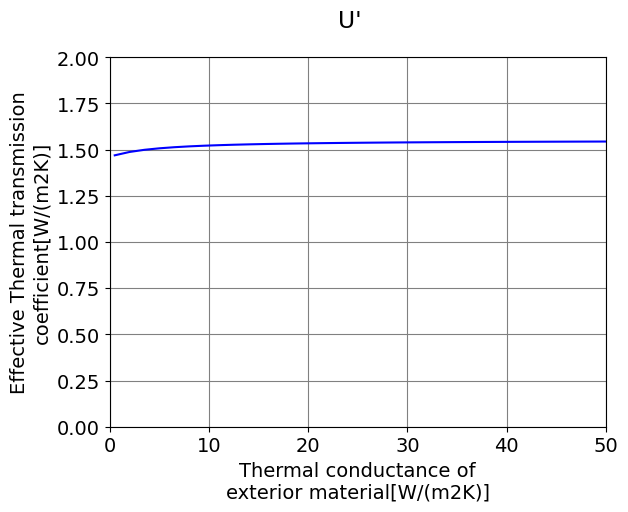

In [14]:
setPltComparison_NoLegend(
    df=df_winter_C_1.query('j_surf == 1000.0'),
    fig_title='U\'',
    x_label='Thermal conductance of\nexterior material[W/(m2K)]',
    y_label='Effective Thermal transmission\ncoefficient[W/(m2K)]',
    x_data_name='C_1',
    y_data_name='u_dash',
    x_scale_interval = 10.0,
    xlim_min=0.0,
    xlim_max=50.0,
    ylim_min=0.0,
    ylim_max=2.0
)
setPltComparison_NoLegend(
    df=df_summer_C_1.query('j_surf == 1000.0'),
    fig_title='U\'',
    x_label='Thermal conductance of\nexterior material[W/(m2K)]',
    y_label='Effective Thermal transmission\ncoefficient[W/(m2K)]',
    x_data_name='C_1',
    y_data_name='u_dash',
    x_scale_interval = 10.0,
    xlim_min=0.0,
    xlim_max=50.0,
    ylim_min=0.0,
    ylim_max=2.0
)

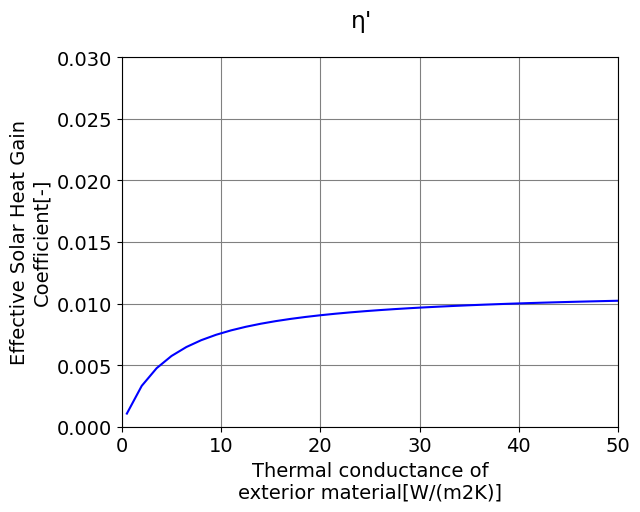

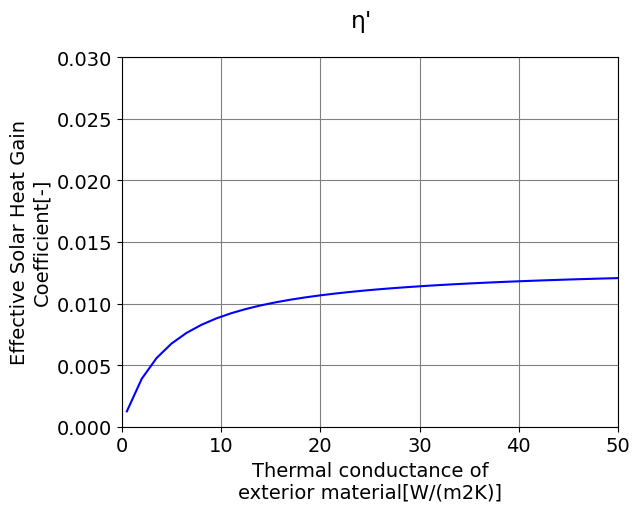

In [15]:
setPltComparison_NoLegend(
    df=df_winter_C_1.query('j_surf == 1000.0'),
    fig_title='η\'',
    x_label='Thermal conductance of\nexterior material[W/(m2K)]',
    y_label='Effective Solar Heat Gain\nCoefficient[-]',
    x_data_name='C_1',
    y_data_name='eta_dash',
    x_scale_interval = 10.0,
    xlim_min=0.0,
    xlim_max=50.0,
    ylim_min=0.0,
    ylim_max=0.03
)
setPltComparison_NoLegend(
    df=df_summer_C_1.query('j_surf == 1000.0'),
    fig_title='η\'',
    x_label='Thermal conductance of\nexterior material[W/(m2K)]',
    y_label='Effective Solar Heat Gain\nCoefficient[-]',
    x_data_name='C_1',
    y_data_name='eta_dash',
    x_scale_interval = 10.0,
    xlim_min=0.0,
    xlim_max=50.0,
    ylim_min=0.0,
    ylim_max=0.03
)

## 通気層に面する面2の放射率による影響の確認

In [16]:
pmo_winter_emissivity_2 = make_pmo_winter()
pmo_summer_emissivity_2 = make_pmo_summer()
pmo_winter_emissivity_2.emissivity_2 = np.arange(0.05, 1.05, 0.05)
pmo_summer_emissivity_2.emissivity_2 = np.arange(0.05, 1.05, 0.05)

In [17]:
df_winter_emissivity_2 = vws.get_datas(pmo=pmo_winter_emissivity_2, hcv_mode=hcv_mode_winter, hrv_mode=hrv_mode_winter)
df_summer_emissivity_2 = vws.get_datas(pmo=pmo_summer_emissivity_2, hcv_mode=hcv_mode_summer, hrv_mode=hrv_mode_summer)


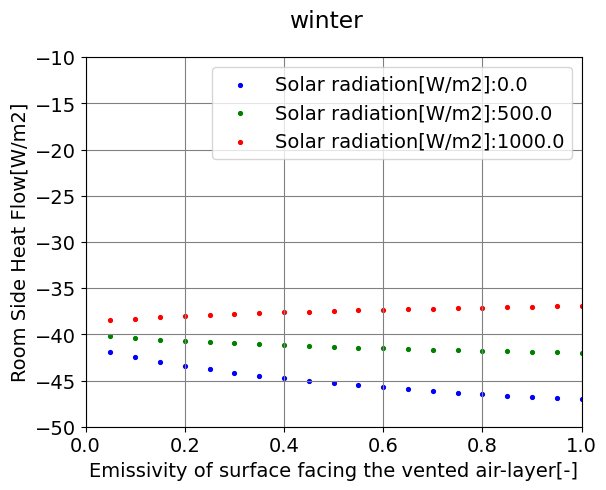

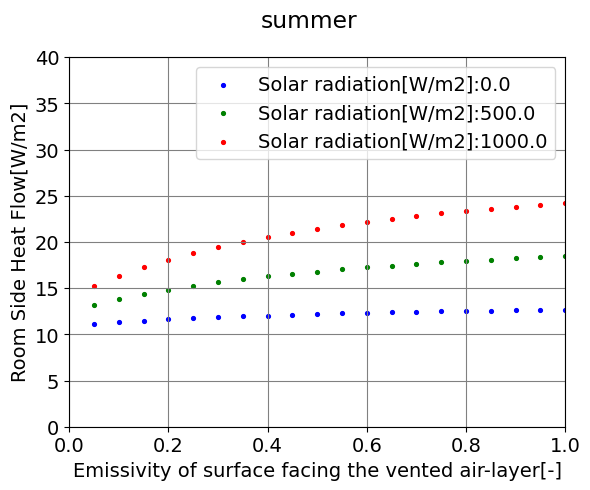

In [18]:
setPltComparison(
    df=df_winter_emissivity_2,
    fig_title='winter',
    x_label='Emissivity of surface facing the vented air-layer[-]',
    y_label='Room Side Heat Flow[W/m2]',
    x_data_name='emissivity_2',
    y_data_name='q_room_side',
    query_label='Solar radiation[W/m2]',
    query_data_name='j_surf',
    query_data_list=pmo_winter_emissivity_2.j_surf,
    xlim_min=0.0,
    xlim_max=1.0,
    ylim_min=-50.0,
    ylim_max=-10.0
)
setPltComparison(
    df=df_summer_emissivity_2,
    fig_title='summer',
    x_label='Emissivity of surface facing the vented air-layer[-]',
    y_label='Room Side Heat Flow[W/m2]',
    x_data_name='emissivity_2',
    y_data_name='q_room_side',
    query_label='Solar radiation[W/m2]',
    query_data_name='j_surf',
    query_data_list=pmo_summer_emissivity_2.j_surf,
    xlim_min=0.0,
    xlim_max=1.0,
    ylim_min=0.0,
    ylim_max=40.0
)

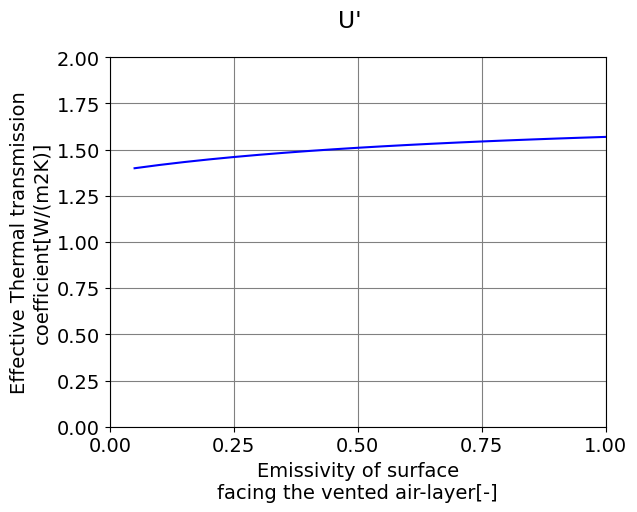

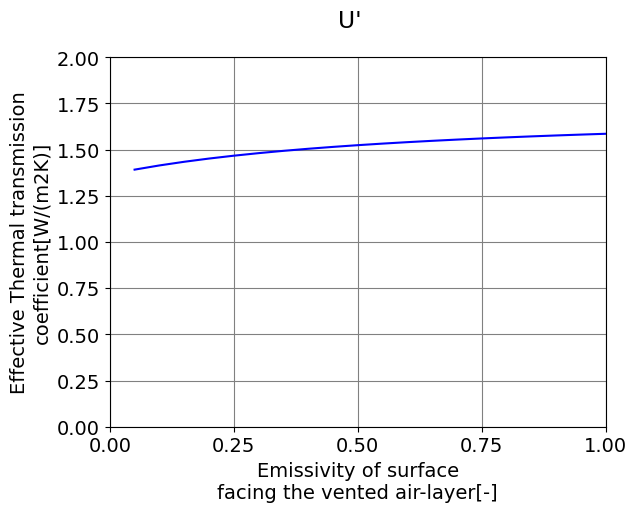

In [19]:
setPltComparison_NoLegend(
    df=df_winter_emissivity_2.query('j_surf == 1000.0'),
    fig_title='U\'',
    x_label='Emissivity of surface\nfacing the vented air-layer[-]',
    y_label='Effective Thermal transmission\ncoefficient[W/(m2K)]',
    x_data_name='emissivity_2',
    y_data_name='u_dash',
    x_scale_interval = 0.25,
    xlim_min=0.0,
    xlim_max=1.0,
    ylim_min=0.0,
    ylim_max=2.0
)
setPltComparison_NoLegend(
    df=df_summer_emissivity_2.query('j_surf == 1000.0'),
    fig_title='U\'',
    x_label='Emissivity of surface\nfacing the vented air-layer[-]',
    y_label='Effective Thermal transmission\ncoefficient[W/(m2K)]',
    x_data_name='emissivity_2',
    y_data_name='u_dash',
    x_scale_interval = 0.25,
    xlim_min=0.0,
    xlim_max=1.0,
    ylim_min=0.0,
    ylim_max=2.0
)

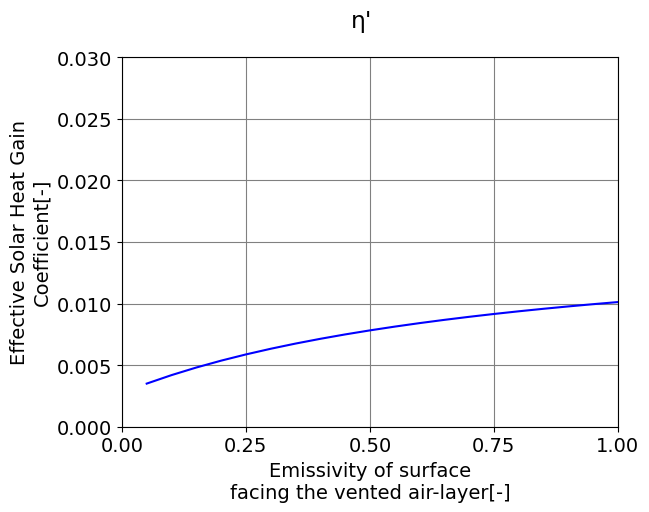

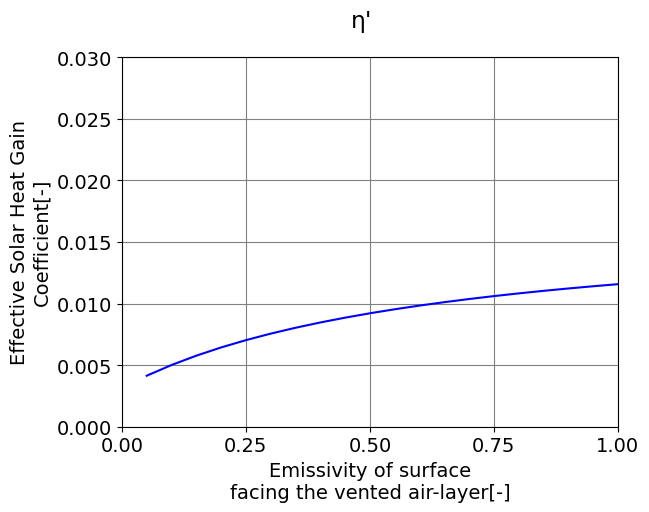

In [20]:
setPltComparison_NoLegend(
    df=df_winter_emissivity_2.query('j_surf == 1000.0'),
    fig_title='η\'',
    x_label='Emissivity of surface\nfacing the vented air-layer[-]',
    y_label='Effective Solar Heat Gain\nCoefficient[-]',
    x_data_name='emissivity_2',
    y_data_name='eta_dash',
    x_scale_interval = 0.25,
    xlim_min=0.0,
    xlim_max=1.0,
    ylim_min=0.0,
    ylim_max=0.03
)
setPltComparison_NoLegend(
    df=df_summer_emissivity_2.query('j_surf == 1000.0'),
    fig_title='η\'',
    x_label='Emissivity of surface\nfacing the vented air-layer[-]',
    y_label='Effective Solar Heat Gain\nCoefficient[-]',
    x_data_name='emissivity_2',
    y_data_name='eta_dash',
    x_scale_interval = 0.25,
    xlim_min=0.0,
    xlim_max=1.0,
    ylim_min=0.0,
    ylim_max=0.03
)